# 04 — Ensemble From Run History (Stacking)

**职责**: 从 `outputs/run_history.csv` 中为每个模型选出历史最优 run，重建单模型后，按 **重建测试 RMSE** 取 **Top-K**（默认 3）基模型做 OOF Stacking（元学习器为 `LinearRegression`）。

**流程**: 读取历史记录 → 按模型选最优 run → 重建单模型 → Top-K Stacking → 保存集成记录

**输入**: `outputs/run_history.csv`, `outputs/models/<run_id>/selected_features.json`, `data/raw/train_data.csv`  
**输出**: `outputs/ensemble_history.csv`, `outputs/figures/ensemble_stacking_*.png`

In [4]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import json
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

from config import DATA_RAW, TARGET, MODEL_DIR, FIG_DIR, RANDOM_STATE
from src.feature_engineering import GroupPCATransformer, build_feature_matrix_for_pca
from src.preprocessing import load_and_clean
from src.models import discover_models

RUN_HISTORY_PATH = MODEL_DIR.parent / 'run_history.csv'
ENSEMBLE_HISTORY_PATH = MODEL_DIR.parent / 'ensemble_history.csv'

SELECT_BY = 'test_rmse'   # 可改成 'cv_rmse'
ENSEMBLE_NOTES = ''
STACK_TOP_K = 3   # Stacking 基模型个数（按 Rebuilt Test RMSE 排序取前 K，需 >=2）

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


def style_ensemble_history(df):
    """最近 5 条 ensemble 记录：RMSE / R² 渐变着色；兼容旧列 stacking_coef_linear/tree。"""
    sub = df.tail(5).copy()
    sty = sub.style
    if 'stacking_rmse' in sub.columns:
        sty = sty.background_gradient(subset=['stacking_rmse'], cmap='RdYlGn_r')
    if 'stacking_r2' in sub.columns:
        sty = sty.background_gradient(subset=['stacking_r2'], cmap='RdYlGn')
    fmt = {}
    if 'stacking_rmse' in sub.columns:
        fmt['stacking_rmse'] = '{:.4f}'
    if 'stacking_r2' in sub.columns:
        fmt['stacking_r2'] = '{:.4f}'
    if 'stacking_coef_linear' in sub.columns:
        fmt['stacking_coef_linear'] = '{:.2%}'
    if 'stacking_coef_tree' in sub.columns:
        fmt['stacking_coef_tree'] = '{:.2%}'
    if fmt:
        sty = sty.format(fmt, na_rep='–')
    return sty


## 1. 从历史记录中为每个模型选最优 run

默认按 `SELECT_BY` 指定的指标选择每个模型的历史最优结果。若你担心测试集泄漏，可以把 `SELECT_BY` 改成 `cv_rmse`。

In [5]:
if not RUN_HISTORY_PATH.exists():
    raise FileNotFoundError(f'Run history not found: {RUN_HISTORY_PATH}')

history = pd.read_csv(RUN_HISTORY_PATH)
required_cols = {'run_id', 'model', 'best_params', 'cv_rmse', 'test_rmse'}
missing = required_cols - set(history.columns)
if missing:
    raise ValueError(f'Missing required columns in run_history.csv: {sorted(missing)}')

if SELECT_BY not in {'cv_rmse', 'test_rmse'}:
    raise ValueError("SELECT_BY must be 'cv_rmse' or 'test_rmse'")

history = history.dropna(subset=[SELECT_BY]).copy()

_fallback_features = None
_latest_nfeat = history['n_features'].iloc[-1]
_compat = history[history['n_features'] == _latest_nfeat]
if len(_compat) < len(history):
    print(f'Filtering to n_features={_latest_nfeat} (compatible with current PCA): '
          f'{len(history)} → {len(_compat)} rows')
    history = _compat
for d in sorted(MODEL_DIR.iterdir(), reverse=True):
    fp = d / 'selected_features.json'
    if d.is_dir() and fp.exists():
        with open(fp) as f:
            _fallback_features = json.load(f)
        print(f'Fallback features from latest run: {d.name} ({len(_fallback_features)} features)')
        break
if _fallback_features is None:
    raise FileNotFoundError('No run directory contains selected_features.json')

history['selected_metric'] = history[SELECT_BY]
history = history.sort_values(['model', 'selected_metric', 'timestamp'])

best_by_model = history.groupby('model', as_index=False).first()
best_by_model = best_by_model.sort_values('selected_metric').reset_index(drop=True)

print(f'\nSelecting best run per model by: {SELECT_BY}')
print(f'Total historical rows: {len(history)}')
print(f'Models selected: {best_by_model["model"].tolist()}')

best_by_model[['model', 'run_id', 'test_rmse', 'n_features']]

Filtering to n_features=92 (compatible with current PCA): 66 → 6 rows
Fallback features from latest run: 20260403_184128 (92 features)

Selecting best run per model by: test_rmse
Total historical rows: 6
Models selected: ['lightgbm', 'xgboost', 'catboost', 'elasticnet', 'lasso', 'random_forest']


,model,run_id,test_rmse,n_features
0,lightgbm,20260403_184128,1.2439,92
1,xgboost,20260403_184128,1.3058,92
2,catboost,20260403_184128,1.3331,92
3,elasticnet,20260403_184128,1.5153,92
4,lasso,20260403_184128,1.6224,92
5,random_forest,20260403_184128,1.7937,92


## 2. 重建各模型并做统一对比

这里不会直接依赖历史保存的 `.pkl`，而是读取每条最优记录对应的 `best_params` 和 `selected_features.json`，在当前统一的数据切分上重新训练并评估。这样对比口径更一致。

若 `selected_features.json` 里含 `pca_*` 列（与 `03_modeling` 中 `GroupPCATransformer` 一致），本单元会先在**训练集**上 fit 分组 PCA，再 transform 训练/测试，否则会出现 `KeyError`。

In [6]:
df = load_and_clean(DATA_RAW)
df = df.sort_values('startdate').reset_index(drop=True)
X_full, y_full, _ = build_feature_matrix_for_pca(df, TARGET)

split_idx = int(len(X_full) * 0.8)
X_train_full, X_test_full = X_full.iloc[:split_idx], X_full.iloc[split_idx:]
y_train, y_test = y_full.iloc[:split_idx], y_full.iloc[split_idx:]

# 与 03_modeling 一致：若历史 run 的 selected_features 含分组 PCA 列名，需先在训练集上 fit GroupPCATransformer
X_raw_train, X_raw_test = X_train_full, X_test_full
_feat_union = set()
for row in best_by_model.itertuples(index=False):
    _rd = MODEL_DIR / row.run_id / 'selected_features.json'
    if _rd.exists():
        with open(_rd) as _f:
            _feat_union.update(json.load(_f))
    else:
        _feat_union.update(_fallback_features)
_missing = [c for c in _feat_union if c not in X_raw_train.columns]
if _missing and any(str(m).startswith('pca_') for m in _missing):
    _gpca = GroupPCATransformer(random_state=RANDOM_STATE, var_threshold=0.95)
    _gpca.fit(X_raw_train)
    X_train_full = _gpca.transform(X_raw_train)
    X_test_full = _gpca.transform(X_raw_test)
    print(f'GroupPCATransformer applied for rebuild/OOF: {X_raw_train.shape[1]} raw cols → {X_train_full.shape[1]} cols')
elif _missing:
    raise KeyError(f'Unknown feature names (not in build_feature_matrix_for_pca and not pca_*): {_missing[:12]}')

registry = discover_models()
selected_models = {}
predictions = {}
base_rows = []

for row in best_by_model.itertuples(index=False):
    name = row.model
    run_id = row.run_id
    if name not in registry:
        print(f'Skip unknown model: {name}')
        continue

    run_dir = MODEL_DIR / run_id
    features_path = run_dir / 'selected_features.json'
    if features_path.exists():
        with open(features_path) as f:
            selected_features = json.load(f)
    else:
        selected_features = _fallback_features
        print(f'  [{name}] run {run_id} missing features json, using fallback')

    best_params = {}
    if isinstance(row.best_params, str) and row.best_params.strip():
        best_params = json.loads(row.best_params)

    pipe = registry[name].build_pipeline()
    if best_params:
        pipe.set_params(**best_params)

    X_train = X_train_full[selected_features]
    X_test = X_test_full[selected_features]
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    rebuilt_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rebuilt_r2 = r2_score(y_test, y_pred)

    selected_models[name] = {
        'run_id': run_id,
        'pipeline': pipe,
        'features': selected_features,
        'best_params': best_params,
    }
    predictions[name] = y_pred
    base_rows.append({
        'Model': name,
        'Source Run': run_id,
        'CV RMSE (history)': round(row.cv_rmse, 4) if pd.notna(row.cv_rmse) else np.nan,
        'Test RMSE (history)': round(row.test_rmse, 4) if pd.notna(row.test_rmse) else np.nan,
        'Rebuilt Test RMSE': round(rebuilt_rmse, 4),
        'Rebuilt Test R²': round(rebuilt_r2, 4),
        'Features': len(selected_features),
    })

base_results = pd.DataFrame(base_rows).set_index('Model').sort_values('Rebuilt Test RMSE')
print(f'Train: {X_train_full.shape}, Test: {X_test_full.shape}')
print(f'Rebuilt models: {list(base_results.index)}')
base_results

GroupPCATransformer applied for rebuild/OOF: 246 raw cols → 92 cols


/Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Train: (300587, 92), Test: (75147, 92)
Rebuilt models: ['lightgbm', 'xgboost', 'catboost', 'elasticnet', 'lasso', 'random_forest']


,Source Run,CV RMSE (history),Test RMSE (history),Rebuilt Test RMSE,Rebuilt Test R²,Features
Model,,,,,,
lightgbm,20260403_184128,2.6103,1.2439,1.2439,0.9617,92
xgboost,20260403_184128,2.6660,1.3058,1.3058,0.9578,92
catboost,20260403_184128,2.7011,1.3331,1.3331,0.9560,92
elasticnet,20260403_184128,2.3174,1.5153,1.5153,0.9432,92
lasso,20260403_184128,2.5814,1.6224,1.6224,0.9348,92
random_forest,20260403_184128,3.2712,1.7937,1.7937,0.9204,92


## 3. OOF Stacking：Top-K 基模型

按 **Rebuilt Test RMSE** 取前 `STACK_TOP_K` 个基模型，`TimeSeriesSplit(5折)` 得到 OOF 预测矩阵后，在 **OOF 上同时试 5 种元融合**：非负凸组合（`SLSQP`，权重和为 1）、反比 OOF RMSE² 加权、`RidgeCV`（时序内层 CV）、**非负 `Lasso`**（`positive=True`，与你先前尝试同类）、**OLS 对照**；**自动选用 OOF RMSE 最低的一种** 去预测测试集。基模型预测通常高度相关，单一 OLS 元回归容易不稳定；本做法等价于在验证思路上做「小型模型选择」。

In [7]:
ranked = base_results.index.tolist()
k = int(min(STACK_TOP_K, len(ranked)))
if k < 2:
    raise ValueError("Need at least 2 rebuilt models for stacking")
stack_names = ranked[:k]

print("Stacking base models (by Rebuilt Test RMSE):")
for m in stack_names:
    rid = selected_models[m]["run_id"]
    rm = base_results.loc[m, "Rebuilt Test RMSE"]
    print(f"  {m}  run={rid}  RMSE={rm}")

tscv = TimeSeriesSplit(n_splits=5)
oof_stack = np.full((len(y_train), k), np.nan)

for train_idx, val_idx in tscv.split(X_train_full):
    for j, name in enumerate(stack_names):
        info = selected_models[name]
        pipe = clone(info["pipeline"])
        feat = info["features"]
        X_tr = X_train_full.iloc[train_idx][feat]
        X_val = X_train_full.iloc[val_idx][feat]
        pipe.fit(X_tr, y_train.iloc[train_idx])
        oof_stack[val_idx, j] = pipe.predict(X_val)

pred_mat_test = np.column_stack([predictions[m] for m in stack_names])
valid = ~np.isnan(oof_stack).any(axis=1)
X_oof = oof_stack[valid]
y_v = y_train.values[valid]
meta_X_test = pred_mat_test


def _oof_rmse(p):
    return float(np.sqrt(mean_squared_error(y_v, p)))


candidates = []

# 1) 非负、和为 1 的凸组合（SLSQP）
from scipy.optimize import minimize


def _mse_w(w):
    return mean_squared_error(y_v, X_oof @ w)


cons = ({"type": "eq", "fun": lambda w: float(np.sum(w) - 1.0)})
bnds = [(0.0, 1.0)] * k
w0 = np.full(k, 1.0 / k)
opt = minimize(_mse_w, w0, method="SLSQP", bounds=bnds, constraints=cons, options={"maxiter": 2000, "ftol": 1e-12})
w_conv = np.clip(opt.x, 0.0, 1.0)
w_conv = w_conv / (w_conv.sum() + 1e-15)
candidates.append(("convex_slsqp", meta_X_test @ w_conv, w_conv, _oof_rmse(X_oof @ w_conv), 0.0))

# 2) 反比 OOF RMSE² 加权
oof_rmse_j = np.array([_oof_rmse(X_oof[:, j]) for j in range(k)])
inv = 1.0 / (oof_rmse_j ** 2 + 1e-12)
w_inv = inv / inv.sum()
candidates.append(("inv_oof_rmse2", meta_X_test @ w_inv, w_inv, _oof_rmse(X_oof @ w_inv), 0.0))

# 3) RidgeCV（时序内层 CV）
from sklearn.linear_model import RidgeCV

n_oof = len(y_v)
n_splits_inner = min(5, max(2, n_oof // 50000))
inner_cv = TimeSeriesSplit(n_splits=n_splits_inner)
ridge = RidgeCV(alphas=np.logspace(-4, 4, 15), cv=inner_cv, fit_intercept=True).fit(X_oof, y_v)
coef_r = np.asarray(ridge.coef_, dtype=float).ravel()
candidates.append(("ridge_cv", ridge.predict(meta_X_test), coef_r, _oof_rmse(ridge.predict(X_oof)), float(ridge.intercept_)))

# 4) 非负系数 Lasso（与你先前尝试类似，作为候选之一）
from sklearn.linear_model import Lasso

lasso_p = Lasso(alpha=1e-3, positive=True, fit_intercept=True, max_iter=8000).fit(X_oof, y_v)
coef_lp = np.asarray(lasso_p.coef_, dtype=float).ravel()
candidates.append(("lasso_positive", lasso_p.predict(meta_X_test), coef_lp, _oof_rmse(lasso_p.predict(X_oof)), float(lasso_p.intercept_)))

# 5) OLS 元回归（对照）
meta_lr = LinearRegression().fit(X_oof, y_v)
coef_lr = np.asarray(meta_lr.coef_, dtype=float).ravel()
candidates.append(("linear_ols", meta_lr.predict(meta_X_test), coef_lr, _oof_rmse(meta_lr.predict(X_oof)), float(meta_lr.intercept_)))

stack_blend_method, stack_pred, meta_coef_vec, best_oof_rmse, stack_intercept = min(candidates, key=lambda t: t[3])

ensemble_rmse = float(np.sqrt(mean_squared_error(y_test, stack_pred)))
ensemble_r2 = float(r2_score(y_test, stack_pred))
ensemble_bias = float(np.mean(y_test.values - stack_pred))

print(f"\n[Stacking] 选用元融合: {stack_blend_method}  (训练集 OOF RMSE={best_oof_rmse:.4f})")
print(f"  intercept={stack_intercept:.4f},  test bias={ensemble_bias:.4f}")
for m, c in zip(stack_names, meta_coef_vec):
    print(f"  coef/weight[{m}] = {c:.4f}")
print("  各候选 OOF RMSE:")
for name, _, _, rms, _ in sorted(candidates, key=lambda t: t[3]):
    print(f"    {name}: {rms:.4f}")

comparison_rows = [
    {
        "Model": m,
        "Type": "Base",
        "RMSE": base_results.loc[m, "Rebuilt Test RMSE"],
        "R²": float(base_results.loc[m, "Rebuilt Test R²"]),
    }
    for m in stack_names
]
comparison_rows.append({"Model": "Stacking", "Type": "Ensemble", "RMSE": ensemble_rmse, "R²": ensemble_r2})
comparison_df = pd.DataFrame(comparison_rows).sort_values("RMSE").reset_index(drop=True)

print("\nComparison:")
comparison_df


Stacking base models (by Rebuilt Test RMSE):
  lightgbm  run=20260403_184128  RMSE=1.2439
  xgboost  run=20260403_184128  RMSE=1.3058
  catboost  run=20260403_184128  RMSE=1.3331


/Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/zhangjiay


[Stacking] 选用元融合: linear_ols  (训练集 OOF RMSE=2.3610)
  intercept=0.1207,  test bias=0.0595
  coef/weight[lightgbm] = -0.0688
  coef/weight[xgboost] = 0.1245
  coef/weight[catboost] = 0.9295
  各候选 OOF RMSE:
    linear_ols: 2.3610
    lasso_positive: 2.3613
    ridge_cv: 2.3614
    convex_slsqp: 2.3653
    inv_oof_rmse2: 2.4257

Comparison:


,Model,Type,RMSE,R²
0,lightgbm,Base,1.243900,0.961700
1,xgboost,Base,1.305800,0.957800
2,catboost,Base,1.333100,0.956000
3,Stacking,Ensemble,1.338061,0.955686


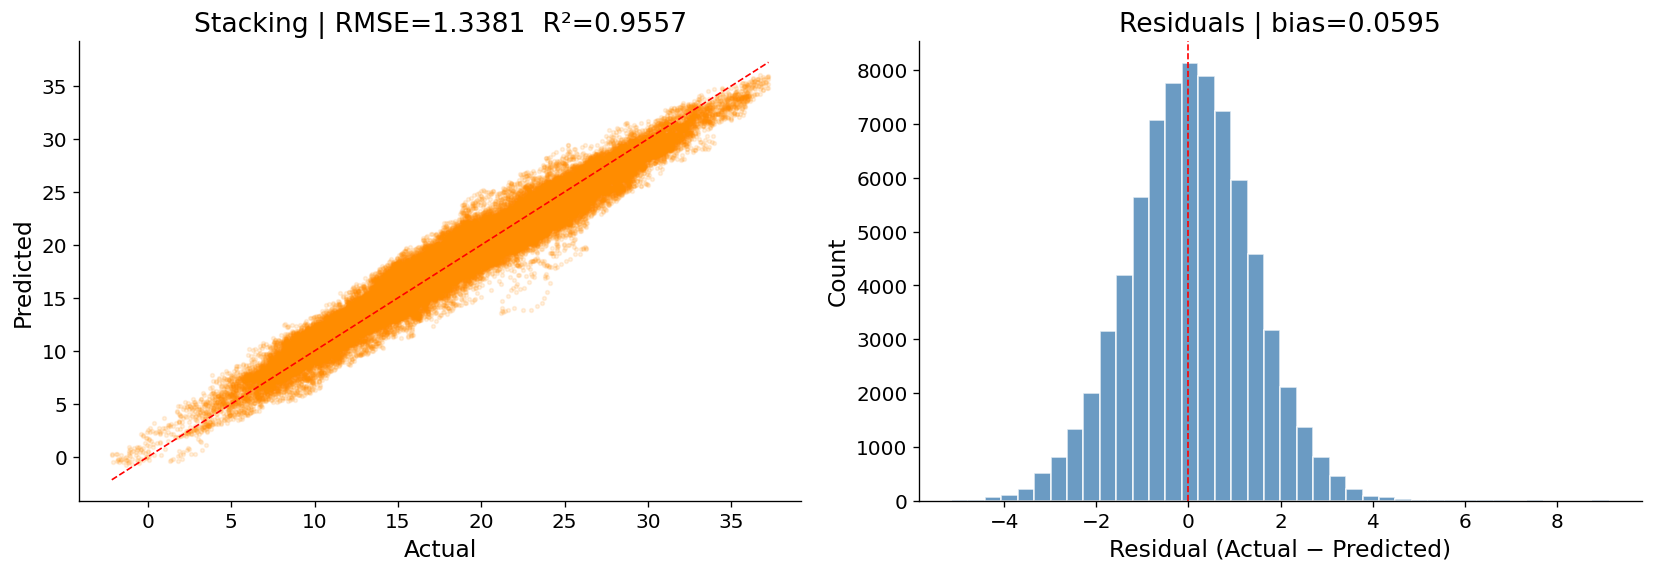

Saved figure -> /Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/outputs/figures/ensemble_stacking_20260403_195330.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(y_test, stack_pred, s=5, alpha=0.12, color='darkorange')
lims = [float(min(y_test.min(), stack_pred.min())), float(max(y_test.max(), stack_pred.max()))]
ax.plot(lims, lims, 'r--', lw=1)
ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.set_title(f'Stacking | RMSE={ensemble_rmse:.4f}  R²={ensemble_r2:.4f}')

residuals = y_test.values - stack_pred
ax = axes[1]
ax.hist(residuals, bins=40, edgecolor='white', color='steelblue', alpha=0.8)
ax.axvline(0, ls='--', color='red', lw=1)
ax.set_xlabel('Residual (Actual − Predicted)')
ax.set_ylabel('Count')
ax.set_title(f'Residuals | bias={ensemble_bias:.4f}')

FIG_DIR.mkdir(parents=True, exist_ok=True)
ensemble_run_id = datetime.now().strftime('%Y%m%d_%H%M%S')
fig_name = f'ensemble_stacking_{ensemble_run_id}.png'
fig_path = FIG_DIR / fig_name
plt.tight_layout()
plt.savefig(fig_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved figure -> {fig_path}')

## 4. 保存 ensemble 结果

将本次 Stacking 的配置和指标追加到 `outputs/ensemble_history.csv`。

In [9]:
record = {
    "ensemble_run_id": ensemble_run_id,
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "select_by": SELECT_BY,
    "stack_top_k": k,
    "stacking_members": json.dumps(stack_names),
    "stacking_member_run_ids": json.dumps([selected_models[m]["run_id"] for m in stack_names]),
    "stacking_member_rmse": json.dumps([round(float(base_results.loc[m, "Rebuilt Test RMSE"]), 4) for m in stack_names]),
    "stacking_blend_method": stack_blend_method,
    "stacking_oof_rmse": round(best_oof_rmse, 4),
    "stacking_meta_coefs": json.dumps([round(float(c), 4) for c in meta_coef_vec]),
    "stacking_rmse": round(ensemble_rmse, 4),
    "stacking_r2": round(ensemble_r2, 4),
    "stacking_intercept": round(float(stack_intercept), 4),
    "stacking_bias": round(ensemble_bias, 4),
    "figure_path": f"outputs/figures/{fig_name}",
    "notes": ENSEMBLE_NOTES,
}

new_row = pd.DataFrame([record])
if ENSEMBLE_HISTORY_PATH.exists():
    ensemble_history = pd.concat([pd.read_csv(ENSEMBLE_HISTORY_PATH), new_row], ignore_index=True)
else:
    ensemble_history = new_row
ensemble_history.to_csv(ENSEMBLE_HISTORY_PATH, index=False)

print(f"Saved ensemble history -> {ENSEMBLE_HISTORY_PATH}")
print(f"Stacking RMSE={ensemble_rmse:.4f}, R²={ensemble_r2:.4f}")

best_base_rmse = min(float(base_results.loc[m, "Rebuilt Test RMSE"]) for m in stack_names)
improvement = (best_base_rmse - ensemble_rmse) / best_base_rmse * 100
print("\nStacking 小结")
print("=" * 34)
print(f"Top-{k} 中最佳单模型 RMSE: {best_base_rmse:.4f}")
print(f"Stacking 测试 RMSE: {ensemble_rmse:.4f}")
print(f"相对最佳基模型: {improvement:+.2f}%")
if improvement > 0:
    print("集成在测试集上优于参与 Stacking 的最优单模型。")
else:
    print("集成未优于最优基模型；若差距大，可直接采用最优单模型。")

_coef = np.asarray(meta_coef_vec, dtype=float)
_tw = np.abs(_coef).sum()
if _tw > 0:
    print("\n元模型系数占比 (|coef| 归一化):")
    for m, c in zip(stack_names, _coef):
        print(f"  {m}: {c / _tw:.1%}")

style_ensemble_history(ensemble_history)


Saved ensemble history -> /Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/outputs/ensemble_history.csv
Stacking RMSE=1.3381, R²=0.9557

Stacking 小结
Top-3 中最佳单模型 RMSE: 1.2439
Stacking 测试 RMSE: 1.3381
相对最佳基模型: -7.57%
集成未优于最优基模型；若差距大，可直接采用最优单模型。

元模型系数占比 (|coef| 归一化):
  lightgbm: -6.1%
  xgboost: 11.1%
  catboost: 82.8%


,ensemble_run_id,timestamp,select_by,best_linear,linear_run_id,linear_rmse,best_tree,tree_run_id,tree_rmse,blending_rmse,stacking_rmse,ensemble_name,ensemble_rmse,ensemble_r2,best_weight_linear,stacking_coef_linear,stacking_coef_tree,stacking_intercept,stacking_bias,figure_path,notes,stacking_r2,stack_top_k,stacking_members,stacking_member_run_ids,stacking_member_rmse,stacking_meta_coefs,stacking_blend_method,stacking_oof_rmse
4,20260325_212227,2026-03-25 21:22:27,test_rmse,elasticnet,20260325_202828,1.723000,lightgbm,20260325_202828,1.209400,–,1.2983,–,–,–,–,32.87%,62.52%,1.046600,-0.557600,outputs/figures/ensemble_stacking_20260325_212227.png,–,0.9583,–,–,–,–,–,–,–
5,20260325_220716,2026-03-25 22:07:16,test_rmse,–,–,–,–,–,–,–,1.4406,–,–,–,–,–,–,0.860600,-0.819200,outputs/figures/ensemble_stacking_20260325_220716.png,–,0.9486,3.000000,"[""lightgbm"", ""catboost"", ""xgboost""]","[""20260325_202828"", ""20260325_202828"", ""20260325_202828""]","[1.2094, 1.3111, 1.3767]","[0.4807, 0.623, -0.1227]",–,–
6,20260325_223717,2026-03-25 22:37:24,test_rmse,–,–,–,–,–,–,–,1.3730,–,–,–,–,–,–,0.972000,-0.712300,outputs/figures/ensemble_stacking_20260325_223717.png,–,0.9533,4.000000,"[""lightgbm"", ""catboost"", ""xgboost"", ""elasticnet""]","[""20260325_202828"", ""20260325_202828"", ""20260325_202828"", ""20260325_202828""]","[1.2094, 1.3111, 1.3767, 1.723]","[0.3809, 0.3928, 0.0, 0.1949]",–,–
7,20260325_230139,2026-03-25 23:01:49,test_rmse,–,–,–,–,–,–,–,1.1993,–,–,–,–,–,–,0.000000,-0.387600,outputs/figures/ensemble_stacking_20260325_230139.png,–,0.9644,3.000000,"[""lightgbm"", ""catboost"", ""xgboost""]","[""20260325_202828"", ""20260325_202828"", ""20260325_202828""]","[1.2094, 1.3111, 1.3767]","[0.5092, 0.4856, 0.0052]",convex_slsqp,2.368500
8,20260403_195330,2026-04-03 19:53:30,test_rmse,–,–,–,–,–,–,–,1.3381,–,–,–,–,–,–,0.120700,0.059500,outputs/figures/ensemble_stacking_20260403_195330.png,,0.9557,3.000000,"[""lightgbm"", ""xgboost"", ""catboost""]","[""20260403_184128"", ""20260403_184128"", ""20260403_184128""]","[1.2439, 1.3058, 1.3331]","[-0.0688, 0.1245, 0.9295]",linear_ols,2.361000
